<a href="https://colab.research.google.com/github/yegnasai/ml-project/blob/main/project_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
np.random.seed(42)

n = 200

age = np.random.randint(18, 61, n)
salary = np.random.randint(20000, 150001, n)

# Generate purchase values
score = (age * 0.05) + (salary / 100000)
probability = 1 / (1 + np.exp(-(score - 2.5)))

purchased = np.random.binomial(1, probability)

data = pd.DataFrame({
    "Age": age,
    "EstimatedSalary": salary,
    "Purchased": purchased
})

data.to_csv("customer_purchase_dataset.csv", index=False)

print("Dataset created successfully!")
print("Number of rows:", len(data))

data.head(10)

Dataset created successfully!
Number of rows: 200


,Age,EstimatedSalary,Purchased
0,56,72662,0
1,46,118506,0
2,32,129751,1
3,60,138906,1
4,25,32688,0
5,38,45342,0
6,56,57157,1
7,36,87863,1
8,40,126308,1
9,28,72083,1


In [3]:
print("Dataset Shape:", data.shape)

print("\nDataset Information:")
print(data.info())

print("\nMissing Values:")
print(data.isnull().sum())

print("\nDataset Statistics:")
print(data.describe())

Dataset Shape: (200, 3)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              200 non-null    int64
 1   EstimatedSalary  200 non-null    int64
 2   Purchased        200 non-null    int64
dtypes: int64(3)
memory usage: 4.8 KB
None

Missing Values:
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

Dataset Statistics:
              Age  EstimatedSalary   Purchased
count  200.000000       200.000000  200.000000
mean    38.955000     83684.210000    0.570000
std     12.754858     39174.251345    0.496318
min     18.000000     20301.000000    0.000000
25%     27.750000     52380.250000    0.000000
50%     41.000000     80924.000000    1.000000
75%     50.000000    118760.000000    1.000000
max     60.000000    149307.000000    1.000000


In [4]:
X = data[["Age", "EstimatedSalary"]]
y = data["Purchased"]

print("Input Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Input Features:
   Age  EstimatedSalary
0   56            72662
1   46           118506
2   32           129751
3   60           138906
4   25            32688

Target:
0    0
1    0
2    1
3    1
4    0
Name: Purchased, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 2)
Testing data: (40, 2)


In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logistic_model = LogisticRegression()

logistic_model.fit(X_train_scaled, y_train)

logistic_prediction = logistic_model.predict(X_test_scaled)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_prediction
)

print("Logistic Regression Accuracy:",
      round(logistic_accuracy * 100, 2), "%")

Logistic Regression Accuracy: 70.0 %


In [7]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

rf_prediction = random_forest_model.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    rf_prediction
)

print("Random Forest Accuracy:",
      round(rf_accuracy * 100, 2), "%")

Random Forest Accuracy: 55.0 %


In [8]:
print("MODEL ACCURACY")
print("-------------------------")

print(
    "Logistic Regression:",
    round(logistic_accuracy * 100, 2),
    "%"
)

print(
    "Random Forest:",
    round(rf_accuracy * 100, 2),
    "%"
)

MODEL ACCURACY
-------------------------
Logistic Regression: 70.0 %
Random Forest: 55.0 %


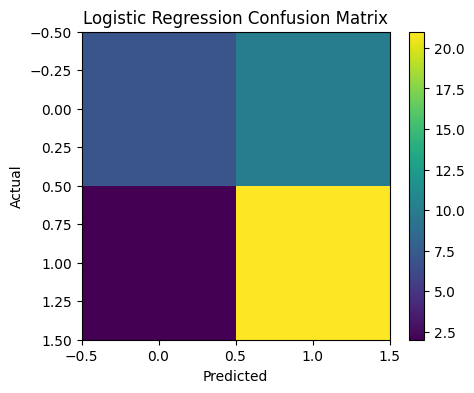

In [9]:
cm_logistic = confusion_matrix(
    y_test,
    logistic_prediction
)

plt.figure(figsize=(5,4))
plt.imshow(cm_logistic)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

plt.show()

In [10]:
age_input = int(input("Enter Customer Age: "))
salary_input = float(input("Enter Estimated Salary: ₹"))

customer = pd.DataFrame({
    "Age": [age_input],
    "EstimatedSalary": [salary_input]
})

print("\nCustomer Details:")
print(customer)

Enter Customer Age: 23
Enter Estimated Salary: ₹20000

Customer Details:
   Age  EstimatedSalary
0   23          20000.0


In [11]:
# Logistic Regression prediction
customer_scaled = scaler.transform(customer)

logistic_result = logistic_model.predict(customer_scaled)[0]
logistic_probability = logistic_model.predict_proba(
    customer_scaled
)[0][1] * 100


# Random Forest prediction
rf_result = random_forest_model.predict(customer)[0]
rf_probability = random_forest_model.predict_proba(
    customer
)[0][1] * 100


print("\n========== PREDICTION RESULT ==========")

print("\nLogistic Regression")

if logistic_result == 1:
    print("Prediction: Customer will PURCHASE")
else:
    print("Prediction: Customer will NOT PURCHASE")

print("Purchase Probability:",
      round(logistic_probability, 2), "%")


print("\nRandom Forest")

if rf_result == 1:
    print("Prediction: Customer will PURCHASE")
else:
    print("Prediction: Customer will NOT PURCHASE")

print("Purchase Probability:",
      round(rf_probability, 2), "%")


========== PREDICTION RESULT ==========

Logistic Regression
Prediction: Customer will NOT PURCHASE
Purchase Probability: 35.11 %

Random Forest
Prediction: Customer will PURCHASE
Purchase Probability: 69.0 %


In [12]:
from IPython.display import display, HTML

logistic_text = "PURCHASE" if logistic_result == 1 else "NOT PURCHASE"
rf_text = "PURCHASE" if rf_result == 1 else "NOT PURCHASE"

html = f"""
<div style="
    width:600px;
    margin:auto;
    padding:25px;
    border-radius:15px;
    border:2px solid #333;
    font-family:Arial;
">

<h1 style="text-align:center;">
Customer Purchase Prediction
</h1>

<hr>

<h3>Customer Details</h3>

<p><b>Age:</b> {age_input}</p>

<p><b>Estimated Salary:</b> ₹{salary_input:,.0f}</p>

<hr>

<h3>Logistic Regression</h3>

<p><b>Prediction:</b> {logistic_text}</p>

<p><b>Purchase Probability:</b>
{logistic_probability:.2f}%</p>

<p><b>Model Accuracy:</b>
{logistic_accuracy*100:.2f}%</p>

<hr>

<h3>Random Forest</h3>

<p><b>Prediction:</b> {rf_text}</p>

<p><b>Purchase Probability:</b>
{rf_probability:.2f}%</p>

<p><b>Model Accuracy:</b>
{rf_accuracy*100:.2f}%</p>

</div>
"""

display(HTML(html))